In [37]:
import os, random, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Optional (prevents TF from grabbing all VRAM at once)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memory growth enabled")
    except Exception as e:
        print("Could not set memory growth:", e)


TF: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Could not set memory growth: Physical devices cannot be modified after being initialized


In [38]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Device:", tf.test.gpu_device_name())


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device: /device:GPU:0


I0000 00:00:1767681637.173530   12000 gpu_device.cc:2020] Created device /device:GPU:0 with 5138 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:01:00.0, compute capability: 8.6


In [39]:
DATA_DIR = "/media/nosrati/925801bb-fbc8-43cf-abaa-72c55c9e5dc6/projects/ai_learning/ml/Ml_projects/car brand/dataset/iran-used-cars-dataset"
SELECTED_CLASSES = ["Peugeot-206", "Pride-131"]  # change to any 2

IMG_SIZE = 224
BATCH_SIZE = 32


In [40]:
import os
print(os.listdir(os.path.join(DATA_DIR, "split")))


['val', 'train', 'test']


In [41]:
import os
import tensorflow as tf

SEED = 42
SPLIT_DIR = os.path.join(DATA_DIR, "split")

train_dir = os.path.join(SPLIT_DIR, "train")
dev_dir   = os.path.join(SPLIT_DIR, "val")   # dev = validation
test_dir  = os.path.join(SPLIT_DIR, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    class_names=SELECTED_CLASSES,
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
)

dev_ds = tf.keras.utils.image_dataset_from_directory(
    dev_dir,
    class_names=SELECTED_CLASSES,
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    class_names=SELECTED_CLASSES,
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False,
)

print("Class order (0/1):", train_ds.class_names)


Found 1074 files belonging to 2 classes.
Found 230 files belonging to 2 classes.
Found 232 files belonging to 2 classes.
Class order (0/1): ['Peugeot-206', 'Pride-131']


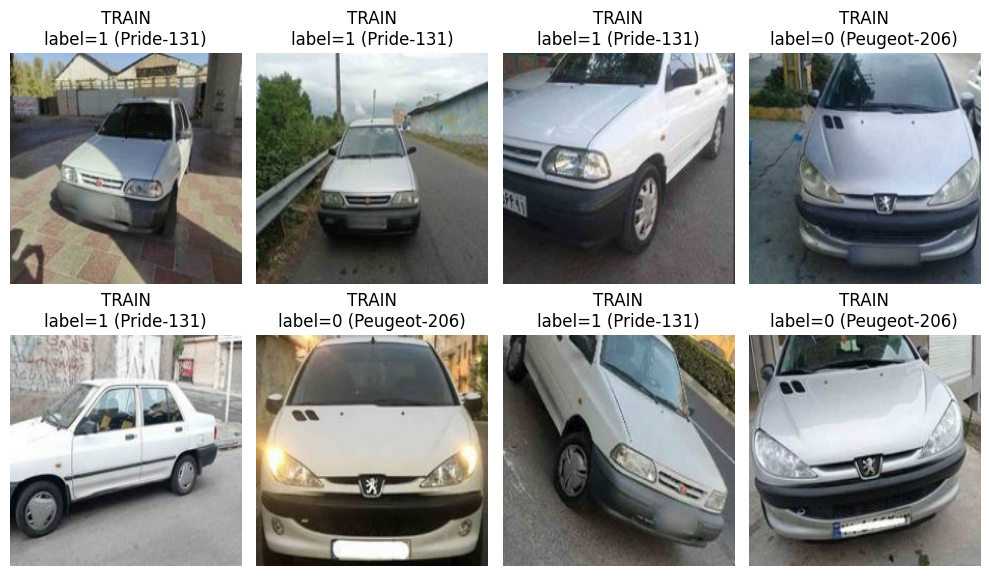

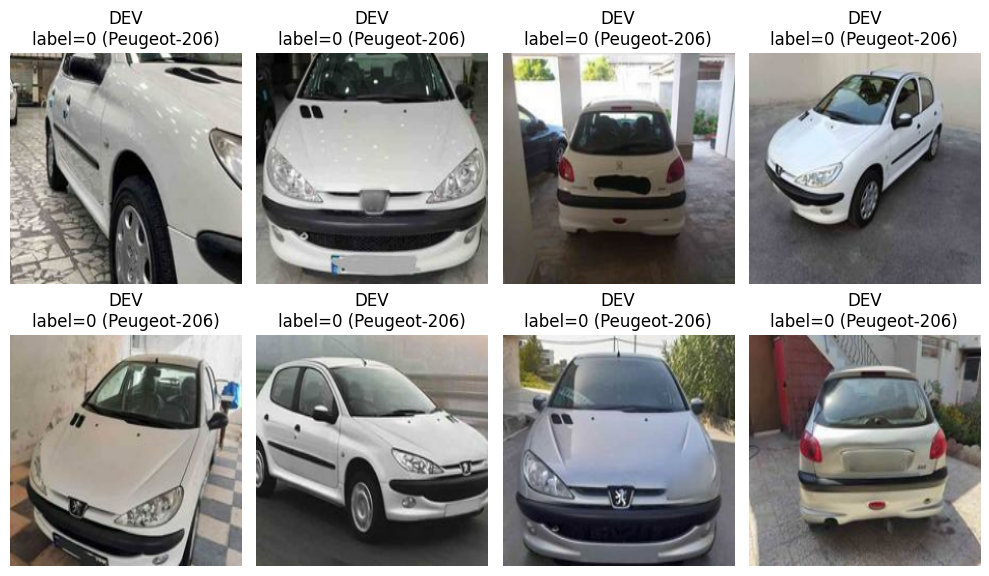

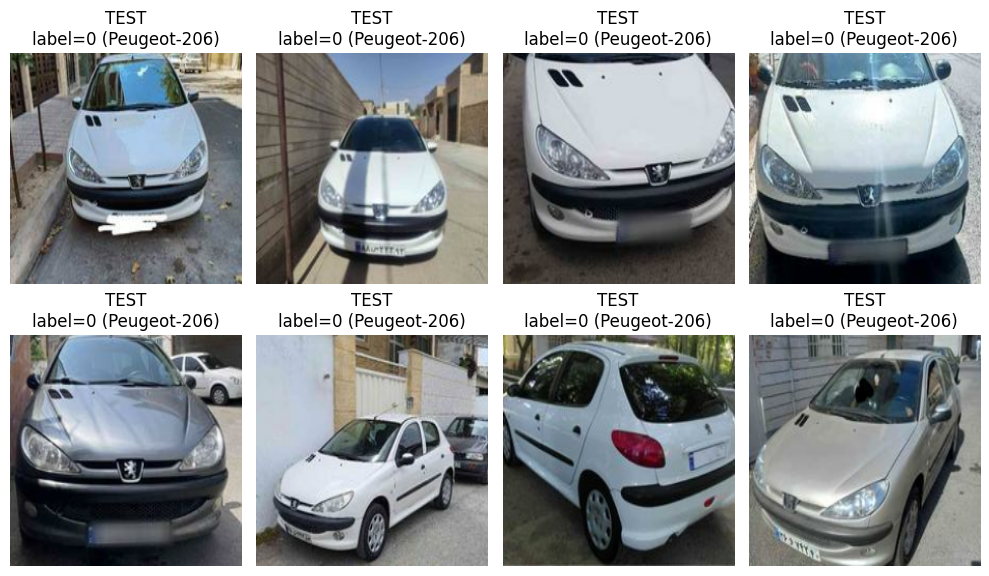

In [42]:
import matplotlib.pyplot as plt

def show_batch(ds, title):
    plt.figure(figsize=(10, 6))
    for images, labels in ds.take(1):
        for i in range(8):
            ax = plt.subplot(2, 4, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            # labels have shape (batch, 1); extract a Python scalar with .item()
            y = int(labels[i].numpy().item())
            plt.title(f"{title}\nlabel={y} ({train_ds.class_names[y]})")
            plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_ds, "TRAIN")
show_batch(dev_ds,   "DEV")
show_batch(test_ds,  "TEST")


In [43]:
import numpy as np

def count_labels(ds):
    c0, c1 = 0, 0
    for _, labels in ds:
        labels = labels.numpy().astype(int).ravel()
        c0 += np.sum(labels == 0)
        c1 += np.sum(labels == 1)
    return c0, c1

print("Train counts:", count_labels(train_ds))
print("Dev counts:  ", count_labels(dev_ds))
print("Test counts: ", count_labels(test_ds))


Train counts: (np.int64(550), np.int64(524))
Dev counts:   (np.int64(118), np.int64(112))
Test counts:  (np.int64(119), np.int64(113))


data aug


In [44]:
import tensorflow as tf
import matplotlib.pyplot as plt

def compare_augs(ds, aug_dict, k=3):
    """
    aug_dict: {"name": augmentation_model, ...}
    k: how many random samples per augmentation to show
    """
    images, labels = next(iter(ds.take(1)))
    img = images[0:1]

    # figure: 1 original + (k per aug)
    cols = 1 + k*len(aug_dict)
    plt.figure(figsize=(3*cols, 3))

    # original
    plt.subplot(1, cols, 1)
    plt.imshow(tf.cast(tf.clip_by_value(img[0], 0, 255), tf.uint8).numpy())
    plt.title("Original")
    plt.axis("off")

    col = 2
    for name, aug in aug_dict.items():
        for i in range(k):
            out = aug(img, training=True)
            plt.subplot(1, cols, col)
            plt.imshow(tf.cast(tf.clip_by_value(out[0], 0, 255), tf.uint8).numpy())
            plt.title(f"{name}\n#{i+1}")
            plt.axis("off")
            col += 1

    plt.tight_layout()
    plt.show()


In [50]:
SEED = 42
aug_light = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomTranslation(0.02, 0.02, seed=SEED),
    tf.keras.layers.RandomRotation(0.01, seed=SEED),
], name="aug_light")


In [51]:
aug_good = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomTranslation(0.08, 0.08, seed=SEED),
    tf.keras.layers.RandomRotation(0.04, seed=SEED),
    tf.keras.layers.RandomZoom(0.12, seed=SEED),
    tf.keras.layers.RandomContrast(0.15, seed=SEED),
], name="aug_good")


In [52]:
aug_strong = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomTranslation(0.12, 0.12, seed=SEED),
    tf.keras.layers.RandomRotation(0.06, seed=SEED),
    tf.keras.layers.RandomZoom(0.18, seed=SEED),
    tf.keras.layers.RandomContrast(0.25, seed=SEED),
], name="aug_strong")


In [63]:
aug_too_much = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomTranslation(0.25, 0.25, seed=SEED),
    tf.keras.layers.RandomRotation(0.20, seed=SEED),
    tf.keras.layers.RandomZoom(0.40, seed=SEED),
    tf.keras.layers.RandomContrast(0.40, seed=SEED),
], name="aug_too_much")


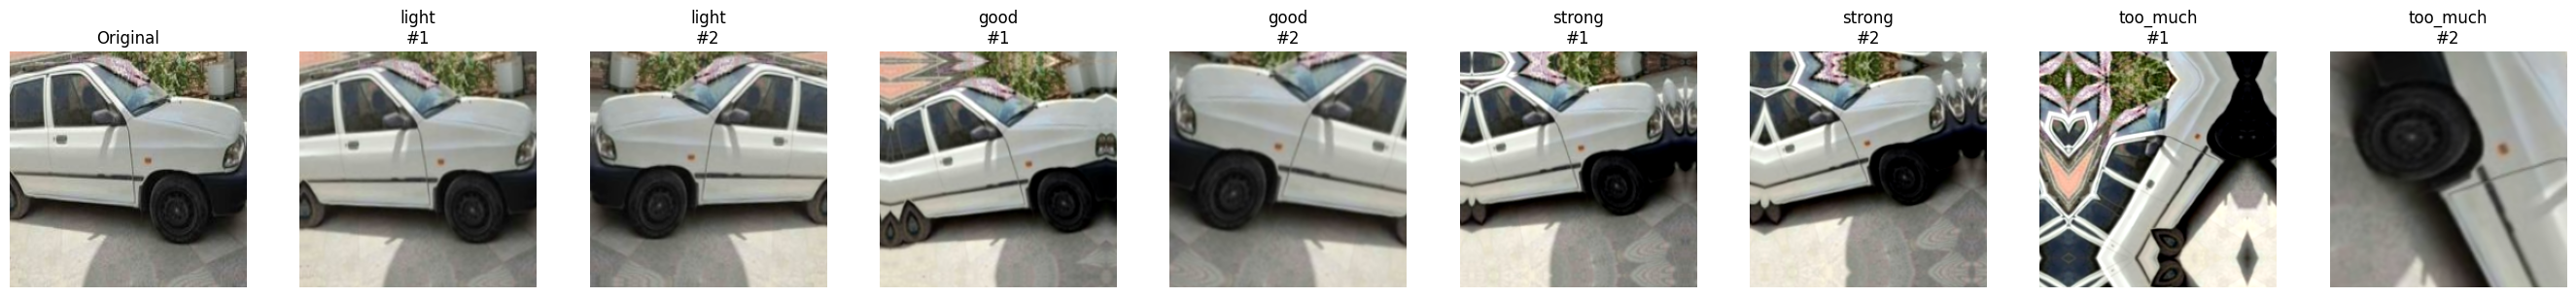

In [61]:
compare_augs(
    train_ds,
    {
        "light": aug_light,
        "good": aug_good,
        "strong": aug_strong,
        "too_much": aug_too_much,
    },
    k=2
)


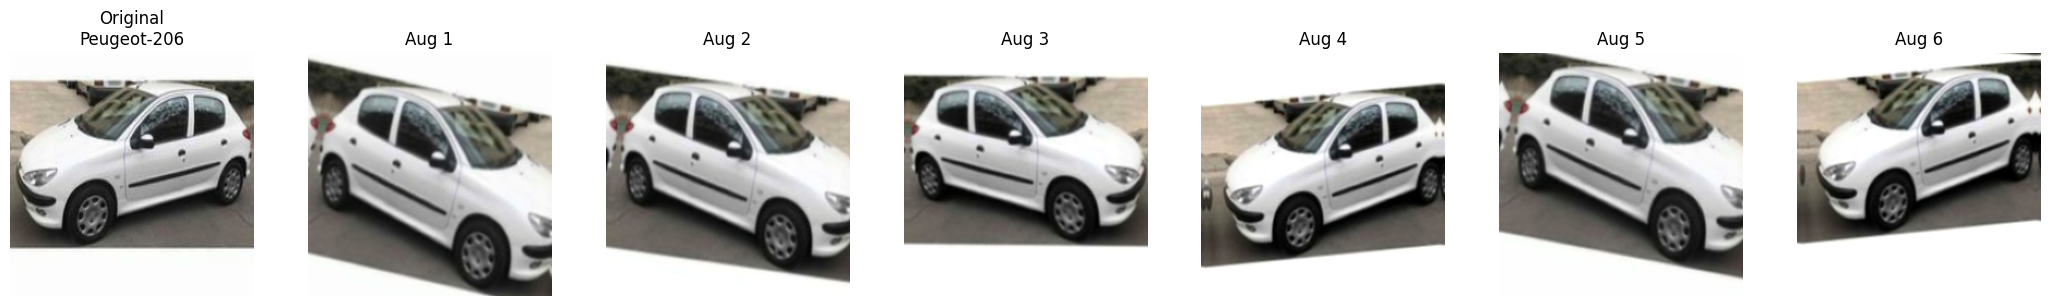

In [46]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def _as_uint8(img):
    img = tf.clip_by_value(img, 0, 255)
    return tf.cast(img, tf.uint8).numpy()

def _label_to_int(labels, i=0):
    # Works for labels shaped (batch,), (batch,1), or even float labels
    y = labels[i].numpy()
    y = np.squeeze(y)          # turn [0.] into 0.
    return int(y)

def show_random_augs(ds, aug, k=6):
    images, labels = next(iter(ds.take(1)))
    img = images[0:1]  # (1, H, W, 3)

    plt.figure(figsize=(3*(k+1), 3))

    # original
    plt.subplot(1, k+1, 1)
    plt.imshow(_as_uint8(img[0]))
    y = _label_to_int(labels, 0)
    plt.title(f"Original\n{ds.class_names[y]}")
    plt.axis("off")

    # k augmentations
    for i in range(k):
        out = aug(img, training=True)
        plt.subplot(1, k+1, i+2)
        plt.imshow(_as_uint8(out[0]))
        plt.title(f"Aug {i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_augs(train_ds, aug, k=6)


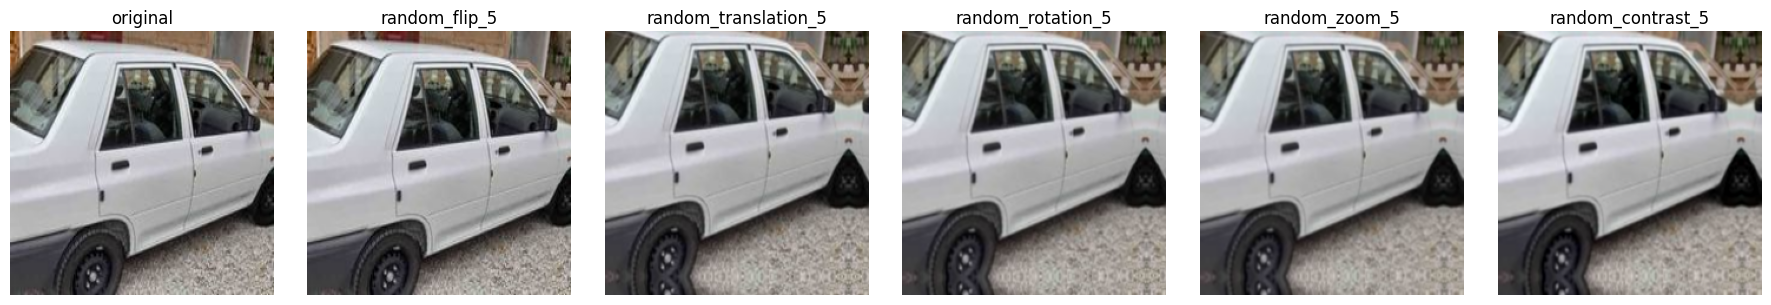

In [47]:
def show_aug_steps(ds, aug):
    images, labels = next(iter(ds.take(1)))
    img = images[0:1]

    steps = [("original", img)]
    x = img
    for layer in aug.layers:
        x = layer(x, training=True)
        steps.append((layer.name, x))

    n = len(steps)
    plt.figure(figsize=(3*n, 3))
    for i, (name, tensor) in enumerate(steps):
        plt.subplot(1, n, i+1)
        plt.imshow(_as_uint8(tensor[0]))
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_aug_steps(train_ds, aug)


In [80]:
import tensorflow as tf

def build_cnn(
    img_size=224,
    base_filters=32,
    dropout=0.3,
    kernel_size=3,
    num_blocks=3,
    l2=0.0,
):
    reg = tf.keras.regularizers.l2(l2) if l2 > 0 else None

    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = aug(inputs)  # uses your aug_strong
    x = tf.keras.layers.Rescaling(1./255)(x)

    filters = base_filters
    for b in range(num_blocks):
        # Conv -> BN -> ReLU
        x = tf.keras.layers.Conv2D(
            filters,
            kernel_size,
            padding="same",
            use_bias=False,              # common when using BatchNorm
            kernel_regularizer=reg
        )(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

        # Downsample
        x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)

        filters *= 2  # double channels each block

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(1, activation="relu")(x)
    return tf.keras.Model(inputs, outputs)

aug = aug_strong  # ✅ use the one you liked

model = build_cnn(img_size=IMG_SIZE, base_filters=32, dropout=0.3)
model.summary()



Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_strong (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_15 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_45 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_46 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_47 (ReLU)                 │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_15     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,049 (367.38 KB)

 Trainable params: 93,601 (365.63 KB)

 Non-trainable params: 448 (1.75 KB)

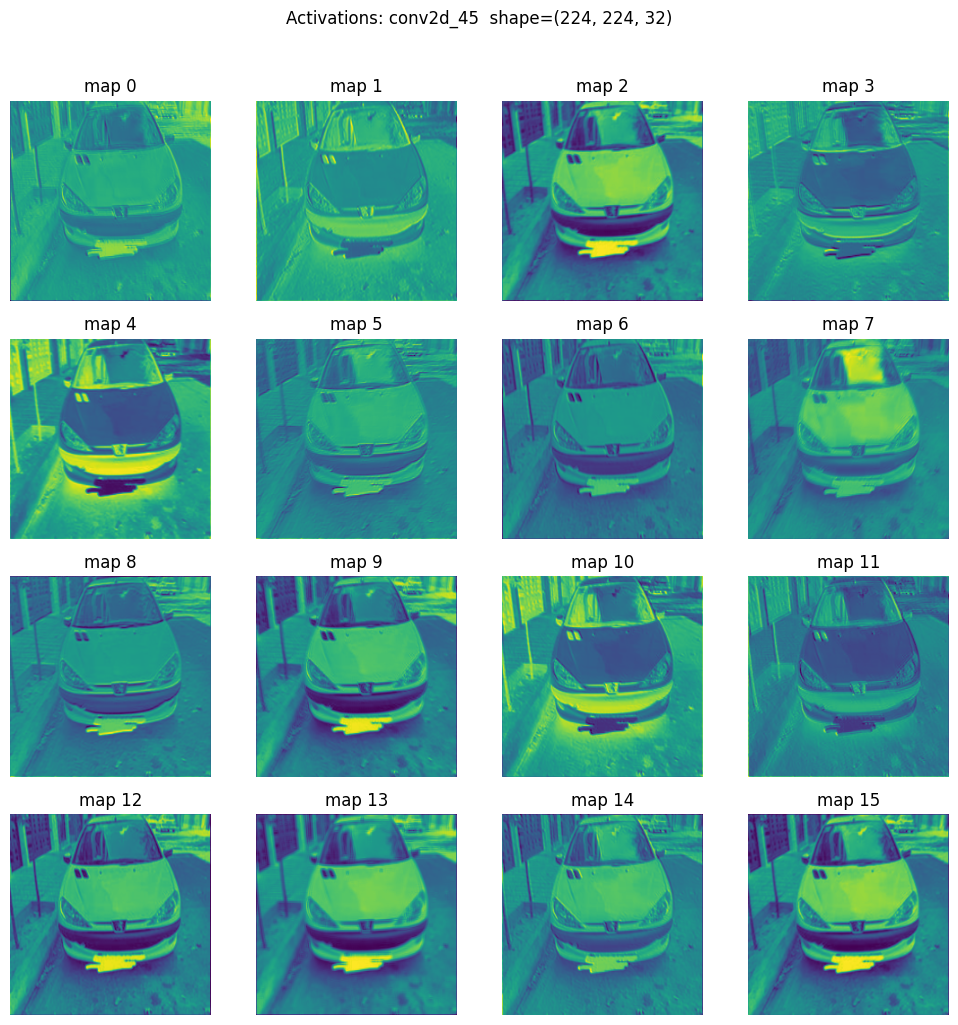

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def show_conv_activations(model, ds, layer_name=None, max_maps=16):
    # pick one image
    images, labels = next(iter(ds.take(1)))
    img = images[0:1]  # (1,H,W,3)

    # choose a conv layer
    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]
    if layer_name is None:
        layer = conv_layers[0]  # first conv by default
    else:
        layer = model.get_layer(layer_name)

    act_model = tf.keras.Model(inputs=model.input, outputs=layer.output)
    act = act_model(img, training=False)[0].numpy()  # (H,W,C)

    # plot some feature maps
    C = act.shape[-1]
    n = min(max_maps, C)
    grid = int(np.ceil(np.sqrt(n)))

    plt.figure(figsize=(10, 10))
    for i in range(n):
        plt.subplot(grid, grid, i+1)
        plt.imshow(act[..., i])
        plt.title(f"map {i}")
        plt.axis("off")
    plt.suptitle(f"Activations: {layer.name}  shape={act.shape}", y=1.02)
    plt.tight_layout()
    plt.show()

# after you build + train your model:
show_conv_activations(model, test_ds, max_maps=16)


In [81]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.3),
]

history = model.fit(
    train_ds,
    validation_data=dev_ds,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.4870 - auc: 0.4902 - loss: 6.0202 - val_accuracy: 0.4913 - val_auc: 0.4567 - val_loss: 7.7195 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.5130 - auc: 0.5060 - loss: 5.7873 - val_accuracy: 0.4826 - val_auc: 0.4236 - val_loss: 2.9897 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.4795 - auc: 0.4739 - loss: 5.6563 - val_accuracy: 0.4957 - val_auc: 0.4578 - val_loss: 6.8518 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.5168 - auc: 0.5171 - loss: 4.5726 - val_accuracy: 0.5130 - val_auc: 0.4873 - val_loss: 7.8537 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.4739 - auc: 0.4731 - loss: 4.6670 - val_accuracy: 0.5130 - val_auc: 0.5000 - val_loss: 7.8488 - learning_rate: 3.0000e-04
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.4823 - auc

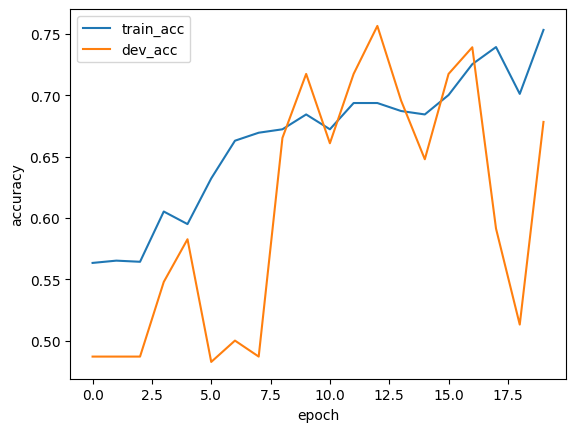

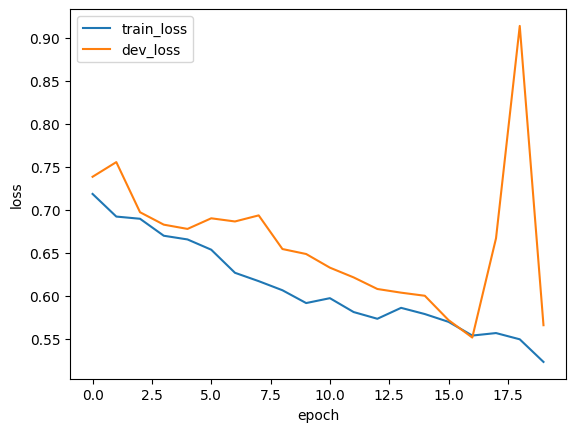

In [78]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="dev_acc")
plt.legend(); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="dev_loss")
plt.legend(); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()


In [79]:
test_metrics = model.evaluate(test_ds, verbose=0)
print(dict(zip(model.metrics_names, test_metrics)))


{'loss': 0.5496813058853149, 'compile_metrics': 0.732758641242981}


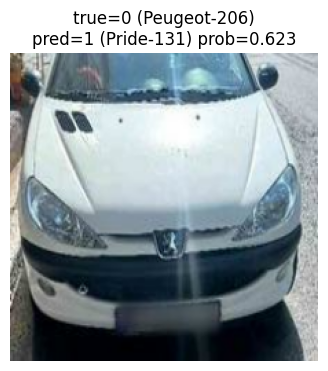

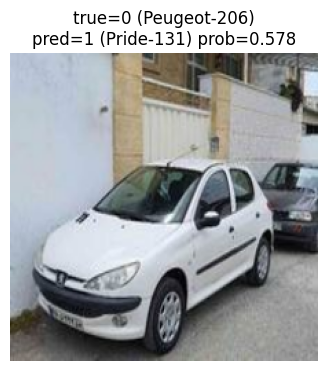

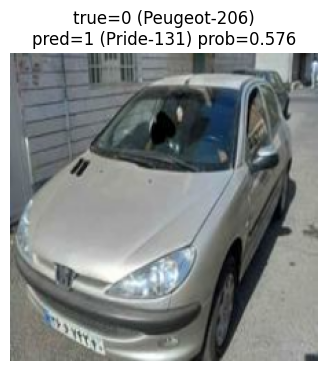

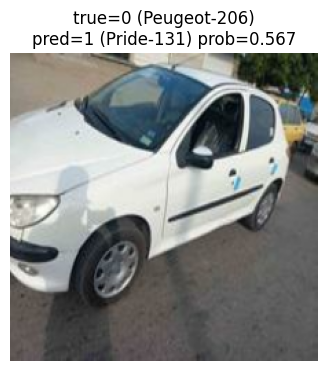

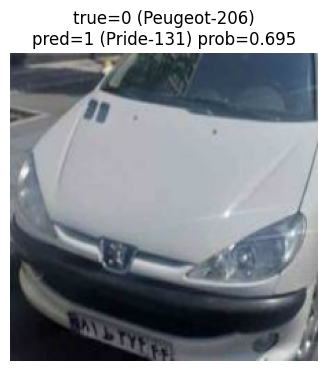

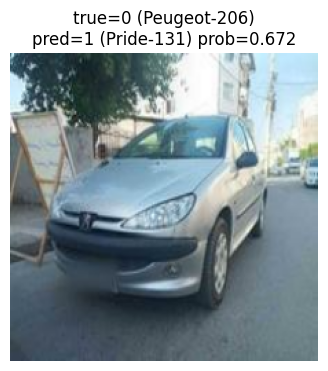

In [72]:
import numpy as np
import matplotlib.pyplot as plt

def show_mistakes(ds, n=8):
    shown = 0
    for images, labels in ds:
        probs = model.predict(images, verbose=0).squeeze()
        preds = (probs >= 0.5).astype(int)
        true  = labels.numpy().astype(int).squeeze()

        wrong = np.where(preds != true)[0]
        for i in wrong:
            plt.figure(figsize=(4,4))
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(
                f"true={true[i]} ({train_ds.class_names[true[i]]})\n"
                f"pred={preds[i]} ({train_ds.class_names[preds[i]]}) prob={probs[i]:.3f}"
            )
            plt.axis("off")
            plt.show()
            shown += 1
            if shown >= n:
                return

show_mistakes(test_ds, n=6)
